In [5]:
%pip install ta


  Using cached ta-0.11.0.tar.gz (25 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29421 sha256=de93b239513840e9d8a1f2a505cd70a91c0135404d70a90dcf82ab2e3da09c15
  Stored in directory: c:\users\lieli\appdata\local\pip\cache\wheels\5c\a1\5f\c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (16, 6)

# Load all 5 stocks
tickers = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']
stocks = {}

for ticker in tickers:
    df = pd.read_csv(f'../data/raw/{ticker}.csv')
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    df.sort_index(inplace=True)
    stocks[ticker] = df
    print(f"{ticker}: {df.shape} | {df.index.min().date()} → {df.index.max().date()}")

print("\nAAPL columns:", stocks['AAPL'].columns.tolist())
print("\nAAPL first 3 rows:")
stocks['AAPL'].head(3)

AAPL: (3774, 5) | 2009-01-02 → 2023-12-29
AMZN: (3774, 5) | 2009-01-02 → 2023-12-29
GOOG: (3774, 5) | 2009-01-02 → 2023-12-29
META: (2923, 5) | 2012-05-18 → 2023-12-29
NVDA: (3774, 5) | 2009-01-02 → 2023-12-29

AAPL columns: ['Close', 'High', 'Low', 'Open', 'Volume']

AAPL first 3 rows:


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400


In [2]:
# ── Missing Values & NaN Audit ─────────────────────────
print("=== Missing Values in Raw Stock Data ===\n")

for ticker in tickers:
    df = stocks[ticker]
    nulls = df.isnull().sum()
    total = len(df)
    print(f"{ticker} ({total} rows):")
    print(nulls.to_string())
    print(f"  → NaN rows: {df.isnull().any(axis=1).sum()}\n")

=== Missing Values in Raw Stock Data ===

AAPL (3774 rows):
Close     0
High      0
Low       0
Open      0
Volume    0
  → NaN rows: 0

AMZN (3774 rows):
Close     0
High      0
Low       0
Open      0
Volume    0
  → NaN rows: 0

GOOG (3774 rows):
Close     0
High      0
Low       0
Open      0
Volume    0
  → NaN rows: 0

META (2923 rows):
Close     0
High      0
Low       0
Open      0
Volume    0
  → NaN rows: 0

NVDA (3774 rows):
Close     0
High      0
Low       0
Open      0
Volume    0
  → NaN rows: 0



In [6]:
# ── NaN from Indicator Warmup Period ───────────────────
# Technical indicators produce NaN for the first N rows
# because there is not enough historical data to compute them.
# This is expected and NOT treated as missing data.

print("=== Expected NaN rows per indicator (warmup period) ===\n")
print(f"SMA 20   → first 19 rows will be NaN (need 20 data points)")
print(f"SMA 50   → first 49 rows will be NaN (need 50 data points)")
print(f"EMA 12   → first row only NaN (ewm initialises from row 1)")
print(f"RSI 14   → first 14 rows will be NaN (need 14 data points)")
print(f"MACD     → first 25 rows will be NaN (EMA 26 needs 26 points)")

print(f"\n=== Actual NaN counts after indicator computation (AAPL) ===")
df_check = stocks['AAPL']
for col in ['SMA_20','SMA_50','EMA_12','EMA_26','MACD','RSI']:
    print(f"  {col}: {df_check[col].isnull().sum()} NaN rows")

print(f"\n=== Handling Strategy ===")
print("Warmup NaNs are retained in the dataset — they are structurally")
print("expected and will be excluded automatically by dropna() during")
print("the correlation analysis in Task 3.")

=== Expected NaN rows per indicator (warmup period) ===

SMA 20   → first 19 rows will be NaN (need 20 data points)
SMA 50   → first 49 rows will be NaN (need 50 data points)
EMA 12   → first row only NaN (ewm initialises from row 1)
RSI 14   → first 14 rows will be NaN (need 14 data points)
MACD     → first 25 rows will be NaN (EMA 26 needs 26 points)

=== Actual NaN counts after indicator computation (AAPL) ===
  SMA_20: 19 NaN rows
  SMA_50: 49 NaN rows
  EMA_12: 11 NaN rows
  EMA_26: 25 NaN rows
  MACD: 25 NaN rows
  RSI: 13 NaN rows

=== Handling Strategy ===
Warmup NaNs are retained in the dataset — they are structurally
expected and will be excluded automatically by dropna() during
the correlation analysis in Task 3.


In [5]:
import ta 

for ticker in tickers:
    df = stocks[ticker]
    
    # Use the 'ta' library functions to add columns directly to your dataframe
    df['SMA_20'] = ta.trend.sma_indicator(df['Close'], window=20)
    df['SMA_50'] = ta.trend.sma_indicator(df['Close'], window=50)
    
    df['EMA_12'] = ta.trend.ema_indicator(df['Close'], window=12)
    df['EMA_26'] = ta.trend.ema_indicator(df['Close'], window=26)
    
    # MACD
    df['MACD'] = ta.trend.macd(df['Close'])
    df['MACD_Signal'] = ta.trend.macd_signal(df['Close'])
    df['MACD_Hist'] = ta.trend.macd_diff(df['Close'])
    
    # RSI
    df['RSI'] = ta.momentum.rsi(df['Close'], window=14)
    
    # Save the updated dataframe back to your dictionary
    stocks[ticker] = df
    print(f"{ticker} ✓ — indicators computed")

AAPL ✓ — indicators computed
AMZN ✓ — indicators computed
GOOG ✓ — indicators computed
META ✓ — indicators computed
NVDA ✓ — indicators computed


In [9]:
def compute_indicators(df):
    # SMA
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['SMA_50'] = df['Close'].rolling(window=50).mean()

    # EMA
    df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
    df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()

    # MACD
    df['MACD'] = df['EMA_12'] - df['EMA_26']
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']

    # RSI
    delta = df['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))

    return df

# Apply to all stocks
for ticker in tickers:
    stocks[ticker] = compute_indicators(stocks[ticker])
    print(f"{ticker} indicators computed ✓")

print("\nAAPL new columns:", stocks['AAPL'].columns.tolist())

AAPL indicators computed ✓
AMZN indicators computed ✓
GOOG indicators computed ✓
META indicators computed ✓
NVDA indicators computed ✓

AAPL new columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'MACD_Hist', 'RSI']


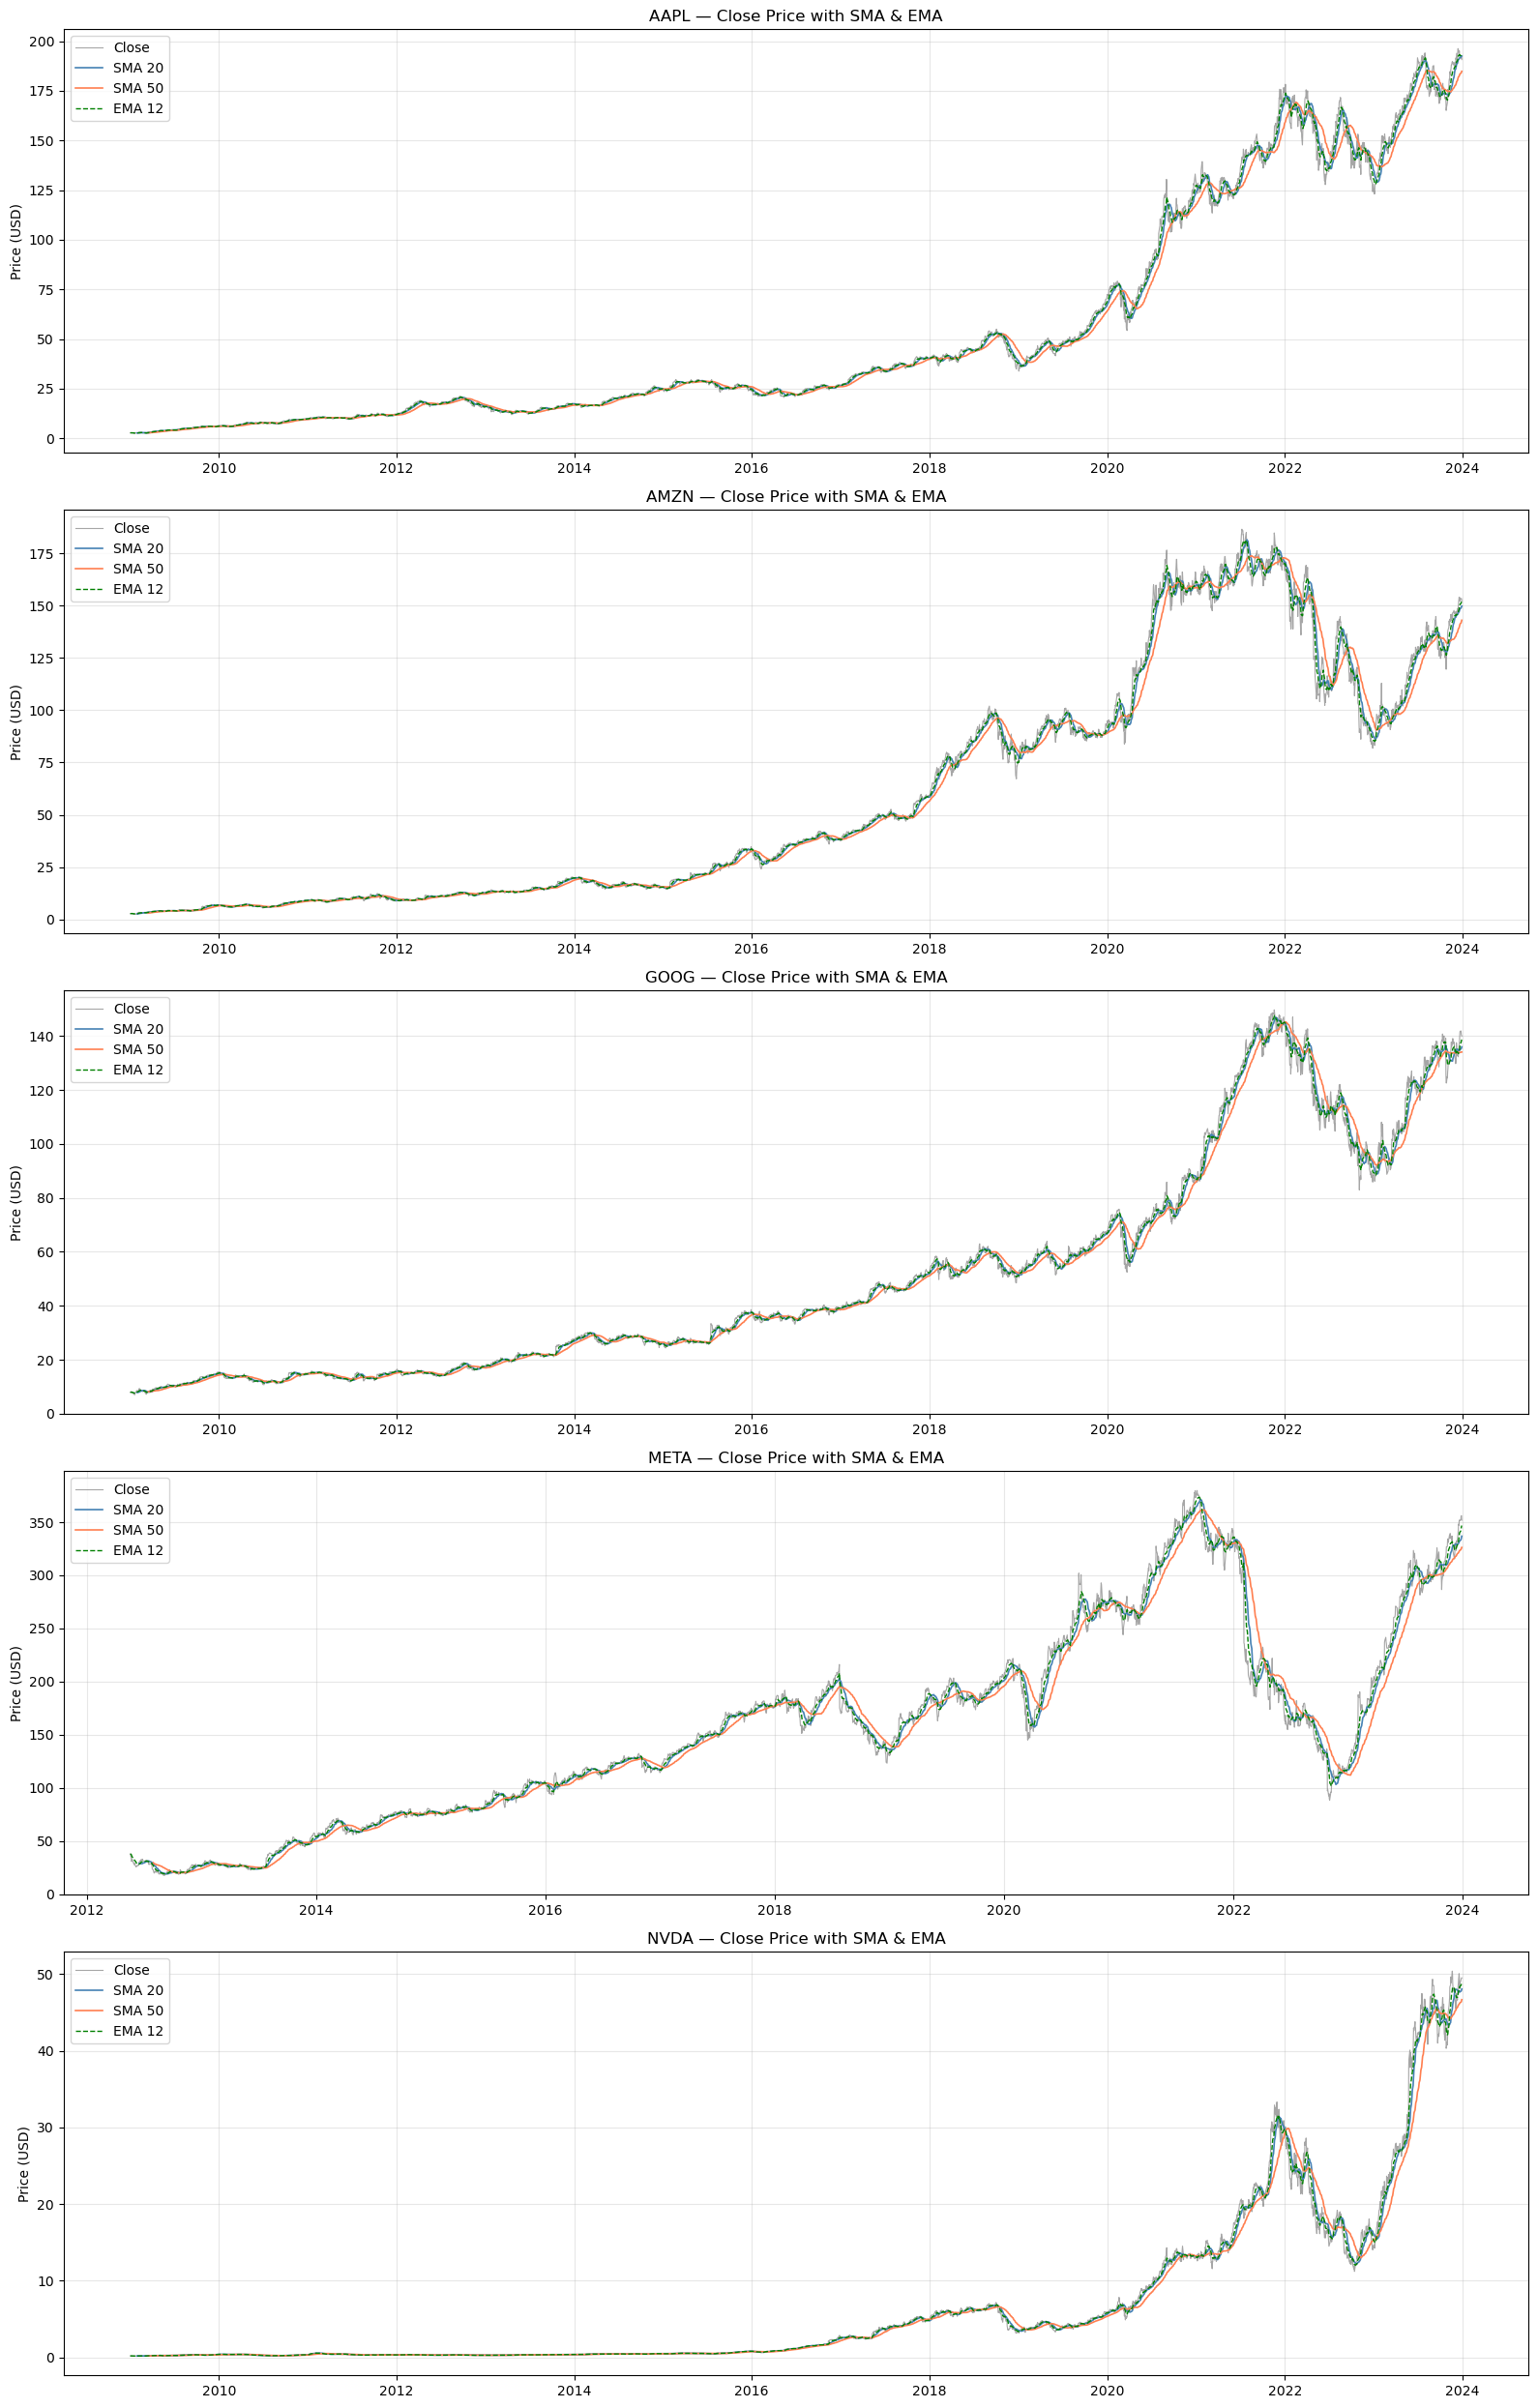

SMA/EMA plot saved.


In [10]:
fig, axes = plt.subplots(5, 1, figsize=(16, 25))

for i, ticker in enumerate(tickers):
    df = stocks[ticker]
    axes[i].plot(df['Close'], label='Close', color='gray', linewidth=0.8, alpha=0.7)
    axes[i].plot(df['SMA_20'], label='SMA 20', color='steelblue', linewidth=1.2)
    axes[i].plot(df['SMA_50'], label='SMA 50', color='coral', linewidth=1.2)
    axes[i].plot(df['EMA_12'], label='EMA 12', color='green', linewidth=1.0, linestyle='--')
    axes[i].set_title(f'{ticker} — Close Price with SMA & EMA')
    axes[i].set_ylabel('Price (USD)')
    axes[i].legend(loc='upper left')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/raw/sma_ema_all_stocks.png', dpi=150)
plt.show()
print("SMA/EMA plot saved.")

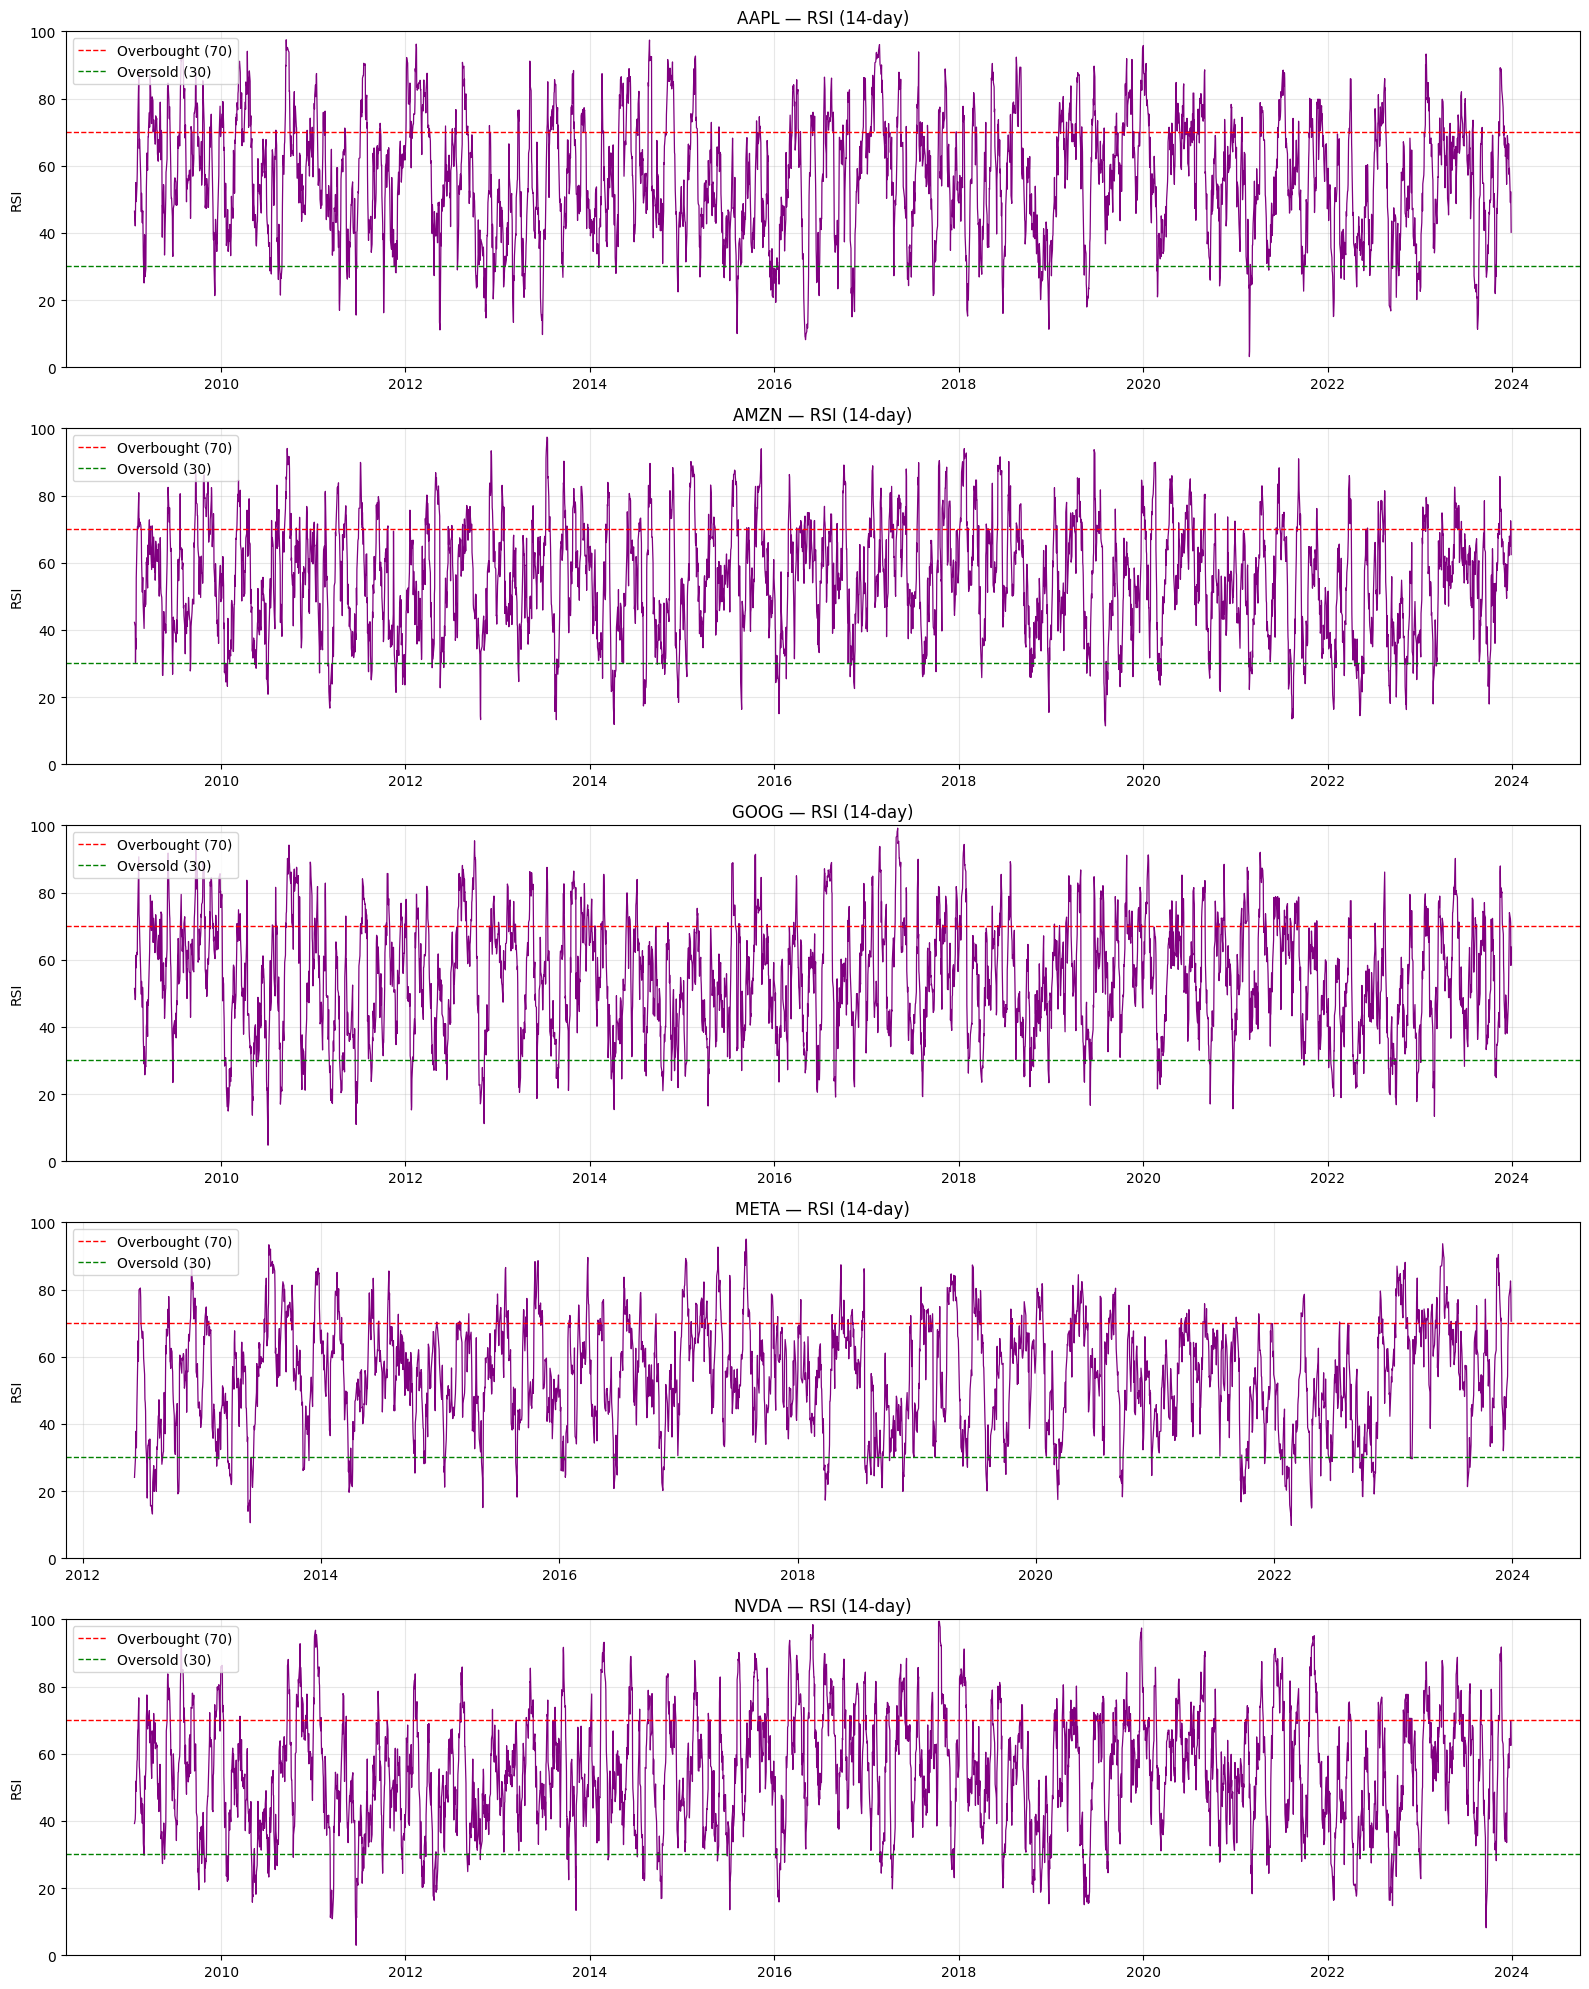

RSI plot saved.


In [4]:
fig, axes = plt.subplots(5, 1, figsize=(16, 20))

for i, ticker in enumerate(tickers):
    df = stocks[ticker]
    axes[i].plot(df['RSI'], color='purple', linewidth=0.9)
    axes[i].axhline(70, color='red', linestyle='--', linewidth=1, label='Overbought (70)')
    axes[i].axhline(30, color='green', linestyle='--', linewidth=1, label='Oversold (30)')
    axes[i].set_title(f'{ticker} — RSI (14-day)')
    axes[i].set_ylabel('RSI')
    axes[i].set_ylim(0, 100)
    axes[i].legend(loc='upper left')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/raw/rsi_all_stocks.png', dpi=150)
plt.show()
print("RSI plot saved.")

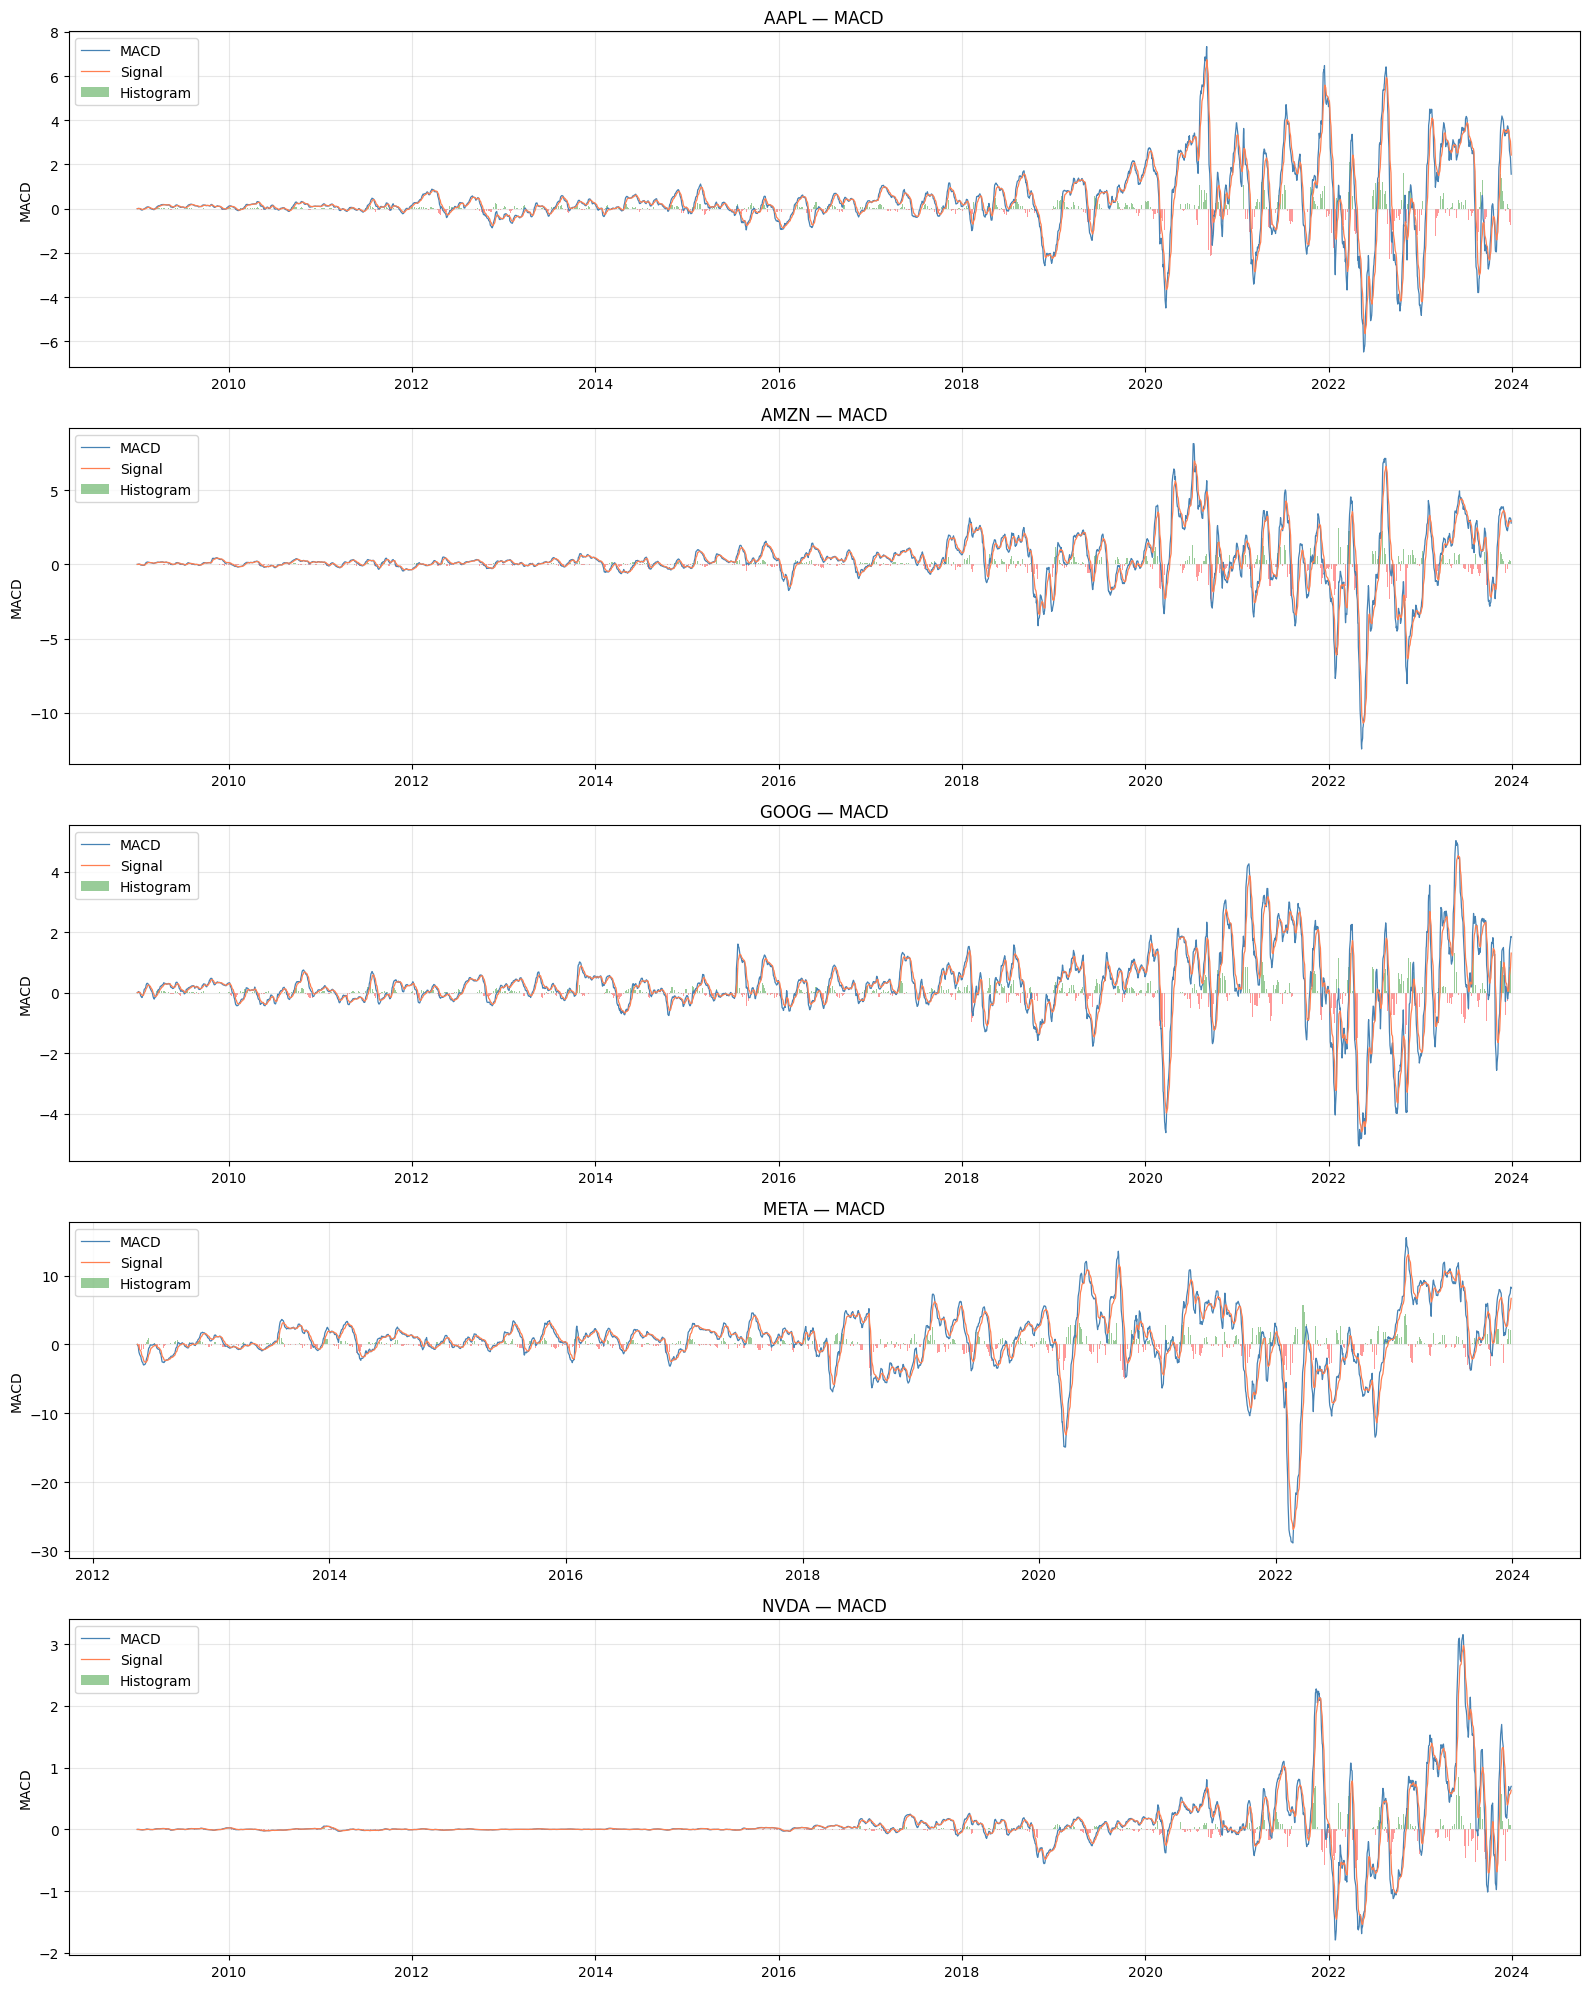

MACD plot saved.


In [5]:
fig, axes = plt.subplots(5, 1, figsize=(16, 20))

for i, ticker in enumerate(tickers):
    df = stocks[ticker]
    axes[i].plot(df['MACD'], label='MACD', color='steelblue', linewidth=0.9)
    axes[i].plot(df['MACD_Signal'], label='Signal', color='coral', linewidth=0.9)
    axes[i].bar(df.index, df['MACD_Hist'],
                color=df['MACD_Hist'].apply(lambda x: 'green' if x >= 0 else 'red'),
                alpha=0.4, label='Histogram')
    axes[i].set_title(f'{ticker} — MACD')
    axes[i].set_ylabel('MACD')
    axes[i].legend(loc='upper left')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/raw/macd_all_stocks.png', dpi=150)
plt.show()
print("MACD plot saved.")

In [6]:
print("=== Indicator Summary (Latest Values) ===\n")
summary = []

for ticker in tickers:
    latest = stocks[ticker].iloc[-1]
    summary.append({
        'Ticker': ticker,
        'Close': round(latest['Close'], 2),
        'SMA_20': round(latest['SMA_20'], 2),
        'SMA_50': round(latest['SMA_50'], 2),
        'RSI': round(latest['RSI'], 2),
        'MACD': round(latest['MACD'], 4),
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))
summary_df

=== Indicator Summary (Latest Values) ===

Ticker  Close  SMA_20  SMA_50   RSI   MACD
  AAPL 190.73  192.49  184.81 40.19 1.5595
  AMZN 151.94  149.82  143.05 62.42 2.7820
  GOOG 139.97  135.98  134.06 63.74 1.8428
  META 351.79  336.87  326.26 70.56 8.1933
  NVDA  49.50   48.05   46.66 62.56 0.6975


,Ticker,Close,SMA_20,SMA_50,RSI,MACD
0,AAPL,190.73,192.49,184.81,40.19,1.5595
1,AMZN,151.94,149.82,143.05,62.42,2.7820
2,GOOG,139.97,135.98,134.06,63.74,1.8428
3,META,351.79,336.87,326.26,70.56,8.1933
4,NVDA,49.50,48.05,46.66,62.56,0.6975
